Youtube Link:  
https://youtu.be/uvLyCMow-h0?si=iK7jmac8MA5YhtzL

In [18]:
import openseespy.opensees as ops
import opsvis as opsv
import matplotlib.pyplot as plt
import numpy as np

In [19]:
ops.wipe()
ops.model('basic', '-ndm', 3, '-ndf', 6)


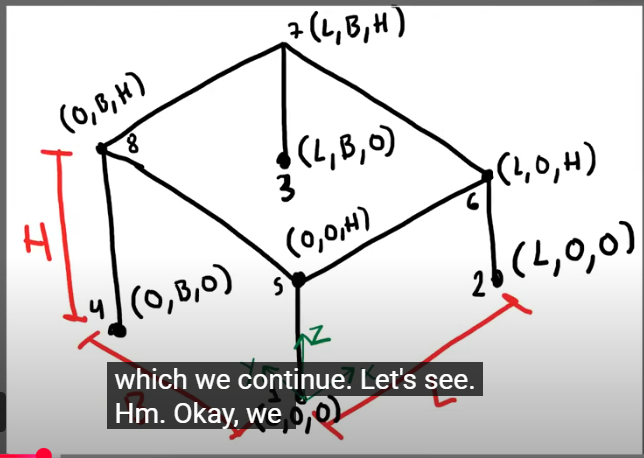
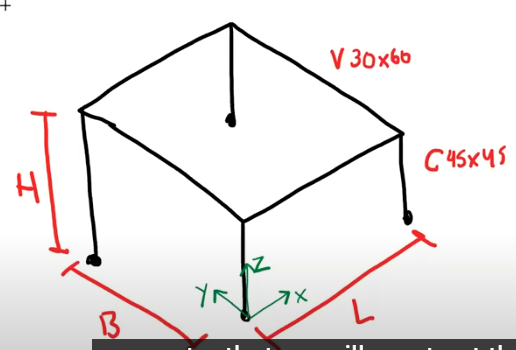

In [20]:
B = 3.2
L = 6.5
H = 2.7

E = 2.1e7
G = E / (2 * (1 + 0.2))

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

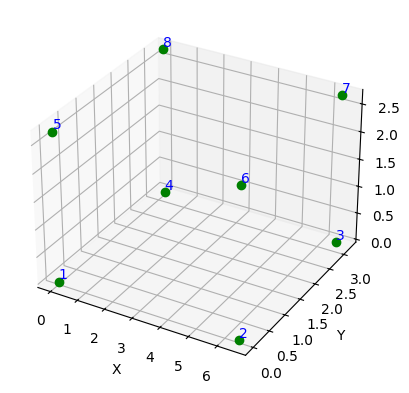

In [21]:
# Define nodes
ops.node(1, 0.0, 0.0, 0.0)
ops.node(2, L, 0.0, 0.0)    
ops.node(3, L, B, 0.0)
ops.node(4, 0.0, B, 0.0) 
ops.node(5, 0.0, 0.0, H)
ops.node(6, L, 0.0, H)
ops.node(7, L, B, H)
ops.node(8, 0.0, B, H)

opsv.plot_model()



In [22]:
# Columns
a = 0.45
A_col = a * a
Iz_col = (a ** 4) / 12
Iy_col = Iz_col
J_col = (2 * Iz_col)


In [23]:
# Beams
b, h = 0.3, 0.6
A_beam = b * h
Iz_beam = (h * b**3) / 12
Iy_beam = (b * h**3) / 12
J_beam = (b * h) * (b**2 + h**2) / 12

In [24]:
ops.geomTransf('Linear', 1, *[1, 0, 0])
ops.geomTransf('Linear', 2, *[0, 0, 1])

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

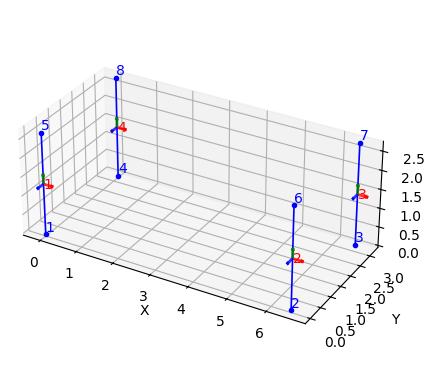

In [25]:
# Columns
ops.element('elasticBeamColumn', 1, 1, 5, A_col, E, G, J_col, Iy_col, Iz_col, 1)
ops.element('elasticBeamColumn', 2, 2, 6, A_col, E, G, J_col, Iy_col, Iz_col, 1)
ops.element('elasticBeamColumn', 3, 3, 7, A_col, E, G, J_col, Iy_col, Iz_col, 1)
ops.element('elasticBeamColumn', 4, 4, 8, A_col, E, G, J_col, Iy_col, Iz_col, 1)
opsv.plot_model()

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

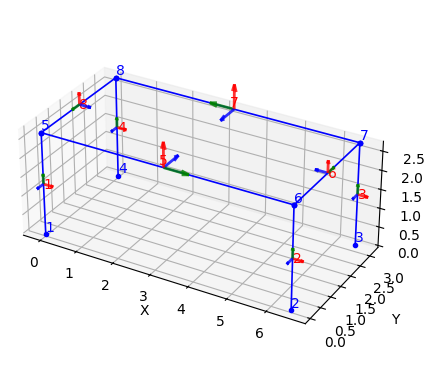

In [26]:
# Beams
ops.element('elasticBeamColumn', 5, 5, 6, A_beam, E, G, J_beam, Iy_beam, Iz_beam, 2)
ops.element('elasticBeamColumn', 6, 6, 7, A_beam, E, G, J_beam, Iy_beam, Iz_beam, 2)
ops.element('elasticBeamColumn', 7, 7, 8, A_beam, E, G, J_beam, Iy_beam, Iz_beam, 2)
ops.element('elasticBeamColumn', 8, 8, 5, A_beam, E, G, J_beam, Iy_beam, Iz_beam, 2)
opsv.plot_model()